In [1]:
import os 
import sys

root_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if root_dir not in sys.path:
    sys.path.append(root_dir)

In [2]:
from common.preprocessing_util import PreprocessingUtil as pp  
import numpy as np

file_path = '../../common/mnist_resnet18_features.npz'

if os.path.exists(file_path):
    print(f"using cached data in {file_path}")
    data = np.load(file_path)
    x = data['X']
    y = data['Y']
else:
    x, y = pp.extract_features_resnet_cnn()

using cached data in ../../common/mnist_resnet18_features.npz


In [3]:
file_path = '../../common/mnist_resnet18_features.npz'

if not os.path.exists(file_path):
    print(f"No existing cache found. Saving features to {file_path}...")
    
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    
    np.savez_compressed(file_path, X=x, Y=y)
    print("Features safely cached!")
else:
    print(f"Cache already exists at {file_path}. Skipping save to prevent overwrite.")

Cache already exists at ../../common/mnist_resnet18_features.npz. Skipping save to prevent overwrite.


In [4]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8)

In [5]:
mu = np.mean(x_train, axis=0)
sigma = np.std(x_train, axis=0)

sigma[sigma == 0] = 1.0

x_train_scaled = (x_train - mu) / sigma
x_test_scaled = (x_test - mu) / sigma

print(f"Old Max: {np.max(x_train):.2f} ---> New Scaled Max: {np.max(x_train_scaled):.2f}")
print(f"New Mean: {np.mean(x_train_scaled):.2f} (Centered at 0)")

Old Max: 11.80 ---> New Scaled Max: 34.98
New Mean: 0.00 (Centered at 0)


In [ ]:
from model import SVM_Multiclass


reg_values = np.logspace(-4, 2, 7)
train_accuracies = []
test_accuracies = []

print("Starting Bias-Variance Sweep...")

for reg in reg_values:
    print(f"Training SVM with Regularization: {reg}...")
    
    svm = SVM_Multiclass(x_train_scaled, y_train)
    
    svm.train(epochs=20, learning_rate=0.0001, regularization=reg)
    
    train_preds = svm.predict(x_train_scaled)
    train_acc = np.sum(train_preds == y_train) / len(y_train)
    train_accuracies.append(train_acc)
    
    test_preds = svm.predict(x_test_scaled)
    test_acc = np.sum(test_preds == y_test) / len(y_test)
    test_accuracies.append(test_acc)

print("Sweep Complete!")

Starting Bias-Variance Sweep...
Training SVM with Regularization: 0.0001...
Epoch 1/20 completed .......
Epoch 2/20 completed .......
Epoch 3/20 completed .......
Epoch 4/20 completed .......
Epoch 5/20 completed .......
Epoch 6/20 completed .......
Epoch 7/20 completed .......
Epoch 8/20 completed .......
Epoch 9/20 completed .......
Epoch 10/20 completed .......
Epoch 11/20 completed .......
Epoch 12/20 completed .......
Epoch 13/20 completed .......
Epoch 14/20 completed .......
Epoch 15/20 completed .......
Epoch 16/20 completed .......
Epoch 17/20 completed .......
Epoch 18/20 completed .......
Epoch 19/20 completed .......
Epoch 20/20 completed .......
Training SVM with Regularization: 0.001...
Epoch 1/20 completed .......
Epoch 2/20 completed .......
Epoch 3/20 completed .......
Epoch 4/20 completed .......
Epoch 5/20 completed .......
Epoch 6/20 completed .......
Epoch 7/20 completed .......
Epoch 8/20 completed .......
Epoch 9/20 completed .......
Epoch 10/20 completed .......

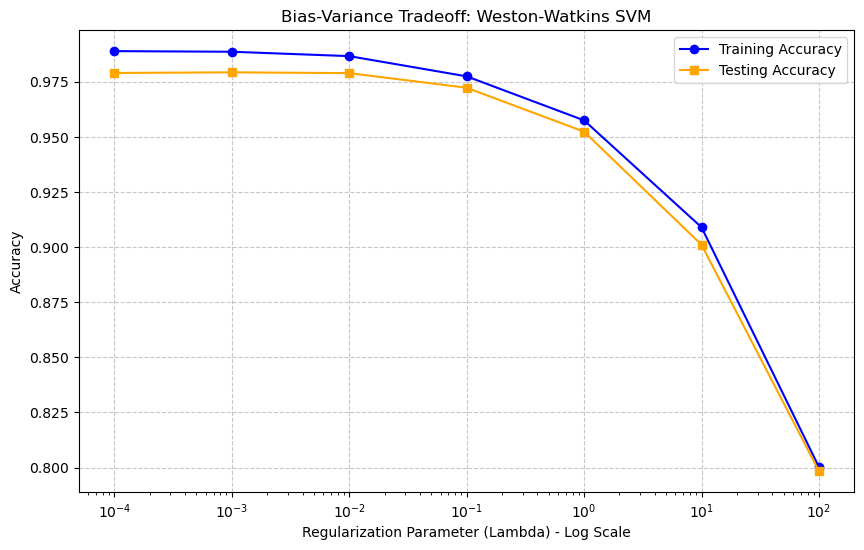

In [ ]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 6))

plt.plot(reg_values, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(reg_values, test_accuracies, label='Testing Accuracy', marker='s', color='orange')

plt.xscale('log')

plt.xlabel('Regularization Parameter (Lambda) - Log Scale')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Weston-Watkins SVM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [14]:
svm = SVM_Multiclass(x_train_scaled, y_train)

# using the best regularization from the bias-variance analysis
svm.train(30, 0.0001, 0.01)
predications = svm.predict(x_test_scaled)

Epoch 1/30 completed .......
Epoch 2/30 completed .......
Epoch 3/30 completed .......
Epoch 4/30 completed .......
Epoch 5/30 completed .......
Epoch 6/30 completed .......
Epoch 7/30 completed .......
Epoch 8/30 completed .......
Epoch 9/30 completed .......
Epoch 10/30 completed .......
Epoch 11/30 completed .......
Epoch 12/30 completed .......
Epoch 13/30 completed .......
Epoch 14/30 completed .......
Epoch 15/30 completed .......
Epoch 16/30 completed .......
Epoch 17/30 completed .......
Epoch 18/30 completed .......
Epoch 19/30 completed .......
Epoch 20/30 completed .......
Epoch 21/30 completed .......
Epoch 22/30 completed .......
Epoch 23/30 completed .......
Epoch 24/30 completed .......
Epoch 25/30 completed .......
Epoch 26/30 completed .......
Epoch 27/30 completed .......
Epoch 28/30 completed .......
Epoch 29/30 completed .......
Epoch 30/30 completed .......


In [ ]:
from 

Final Test Accuracy: 97.88%
